In [2]:
from casadi import *

In [3]:
model_name = 'UR5';

# States
q1_1 = SX.sym('q1_1');q1_2 = SX.sym('q1_2');q1_3 = SX.sym('q1_3');
q1_4 = SX.sym('q1_4');q1_5 = SX.sym('q1_5');q1_6 = SX.sym('q1_6');
dt = SX.sym('dt');

# dummy states
d1_1 = SX.sym('d1_1');d1_2 = SX.sym('d1_2');d1_3 = SX.sym('d1_3');
d1_4 = SX.sym('d1_4');d1_5 = SX.sym('d1_5');d1_6 = SX.sym('d1_6');

# Controls
u1_1 = SX.sym('u1_1');u1_2 = SX.sym('u1_2');u1_3 = SX.sym('u1_3');
u1_4 = SX.sym('u1_4');u1_5 = SX.sym('u1_5');u1_6 = SX.sym('u1_6');

# Slack controls
s1_1 = SX.sym('s1_1');s1_2 = SX.sym('s1_2');s1_3 = SX.sym('s1_3');
s1_4 = SX.sym('s1_4');s1_5 = SX.sym('s1_5');s1_6 = SX.sym('s1_6');

# acceleration controls
a1_1 = SX.sym('a1_1');a1_2 = SX.sym('a1_2');a1_3 = SX.sym('a1_3');
a1_4 = SX.sym('a1_4');a1_5 = SX.sym('a1_5');a1_6 = SX.sym('a1_6');

sym_x_short = vertcat(q1_1, q1_2, q1_3, q1_4, q1_5, q1_6);
sym_u_short = vertcat(u1_1, u1_2, u1_3, u1_4, u1_5, u1_6);
sym_a_short = vertcat(a1_1, a1_2, a1_3, a1_4, a1_5, a1_6);
sym_x = vertcat(q1_1, q1_2, q1_3, q1_4, q1_5, q1_6,
                u1_1, u1_2, u1_3, u1_4, u1_5, u1_6, dt,
                d1_1, d1_2, d1_3, d1_4, d1_5, d1_6);



slack_array = vertcat(s1_1, s1_2, s1_3, s1_4, s1_5, s1_6);
sym_u = vertcat(a1_1, a1_2, a1_3, a1_4, a1_5, a1_6, s1_1, s1_2, s1_3, s1_4, s1_5, s1_6);

            
            
p_human_spheres_1 = SX.sym('human_spheres_1',4,14);
p_final_cart = SX.sym('cart_goal',3);

temp_1 = horzsplit(p_human_spheres_1);
sym_p = vertcat(vcat(temp_1), p_final_cart);


expr_f_expl = vcat([dt*vcat([sym_u_short]), dt*vcat([sym_a_short]), 0.0, slack_array]) # simple integrator

In [4]:
expr_f_expl

SX([(dt*u1_1), (dt*u1_2), (dt*u1_3), (dt*u1_4), (dt*u1_5), (dt*u1_6), (dt*a1_1), (dt*a1_2), (dt*a1_3), (dt*a1_4), (dt*a1_5), (dt*a1_6), 0, s1_1, s1_2, s1_3, s1_4, s1_5, s1_6])

In [5]:
## Forward kinematics
# from auto_transform
# 1 joint
# base_link_||_shoulder_link

TB1=vertcat(
horzcat(cos(q1_1), -sin(q1_1), 0,                                   0),
horzcat(sin(q1_1),  cos(q1_1), 0,                                   0),
horzcat(      0,        0, 1, 0.089159000000000002139621813057602),
horzcat(      0,        0, 0,                                   1)
);


# 2 joint
# shoulder_link_||_upper_arm_link
T12=vertcat(
horzcat(-sin(q1_2), 0,  cos(q1_2),       0),
horzcat(       0, 1,        0, 0.13585),
horzcat(-cos(q1_2), 0, -sin(q1_2),       0),
horzcat(       0, 0,        0,       1),
 );


# 3 joint
# upper_arm_link_||_forearm_link
T23=vertcat(
horzcat( cos(q1_3), 0, sin(q1_3),       0),
horzcat(       0, 1,       0, -0.1197),
horzcat(-sin(q1_3), 0, cos(q1_3),   0.425),
horzcat(       0, 0,       0,       1)
       );

# 4 joint
# forearm_link_||_wrist_1_link
T34=vertcat(
horzcat(-sin(q1_4), 0,  cos(q1_4),       0),
horzcat(       0, 1,        0,       0),
horzcat(-cos(q1_4), 0, -sin(q1_4), 0.39225),
horzcat(       0, 0,        0,       1)
       );

# 5 joint
# wrist_1_link_||_wrist_2_link
T45=vertcat(
horzcat(cos(q1_5), -sin(q1_5), 0,     0),
horzcat(sin(q1_5),  cos(q1_5), 0, 0.093),
horzcat(      0,        0, 1,     0),
horzcat(      0,        0, 0,     1)
       );

# 6 joint
# wrist_2_link_||_wrist_3_link
T56=vertcat(
horzcat( cos(q1_6), 0, sin(q1_6),       0),
horzcat(       0, 1,       0,       0),
horzcat(-sin(q1_6), 0, cos(q1_6), 0.09465),
horzcat(       0, 0,       0,       1)
       );

T6tool =  SX([
[    0.0000,   -1.0000,         0,         0],
[    1.0000,    0.0000,         0,    0.0823],
[         0,         0,    1.0000,         0],
[         0,         0,         0,    1.0000]
]);

TP1_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0679],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);

TP2_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,           0],
[         0,         0,    1.0000,      0.2125],
[         0,         0,         0,      1.0000]
]);

TP3_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0679],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);

TP4_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,           0],
[         0,         0,    1.0000,      0.1294],
[         0,         0,         0,      1.0000]
]);

TP5_shift =  SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,           0],
[         0,         0,    1.0000,      0.2589],
[         0,         0,         0,      1.0000]
]);

TP6_shift = SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0465],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);

TP7_shift = SX([
[    1.0000,         0,         0,           0],
[         0,    1.0000,         0,      0.0411],
[         0,         0,    1.0000,           0],
[         0,         0,         0,      1.0000]
]);
# here we need to find points from j2 to end-effector
T1 = mtimes(TB1,T12);
T2 = mtimes(T1,T23);
T3 = mtimes(T2,T34); 
T4 = mtimes(T3,T45); 
T5 = mtimes(T4,T56); 
T6 = mtimes(T5,T6tool);
Tp1 = mtimes(TB1,TP1_shift);
Tp2 = mtimes(T1,TP2_shift);
Tp3 = mtimes(T2,TP3_shift);
Tp4 = mtimes(T2,TP4_shift);
Tp5 = mtimes(T2,TP5_shift);
Tp6 = mtimes(T3,TP6_shift);
Tp7 = mtimes(T5,TP7_shift);


#T_calibration = T6_1*T7end*Tend2tool;
F_cart_1 = horzcat(Tp1[0:3,3], Tp2[0:3,3], Tp3[0:3,3], Tp4[0:3,3], Tp5[0:3,3], Tp6[0:3,3], Tp7[0:3,3]);

## Velocities
Jv1_1 = jtimes(Tp1[0:3,3], sym_x_short.T, sym_u_short.T);
Jv2_1 = jtimes(Tp2[0:3,3], sym_x_short.T, sym_u_short.T);
Jv3_1 = jtimes(Tp3[0:3,3], sym_x_short.T, sym_u_short.T);
Jv4_1 = jtimes(Tp4[0:3,3], sym_x_short.T, sym_u_short.T);
Jv5_1 = jtimes(Tp5[0:3,3], sym_x_short.T, sym_u_short.T);
Jv6_1 = jtimes(Tp6[0:3,3], sym_x_short.T, sym_u_short.T);
Jv7_1 = jtimes(Tp7[0:3,3], sym_x_short.T, sym_u_short.T);


vels_array_1 = vertcat(Jv1_1[0]**2+Jv1_1[1]**2+Jv1_1[2]**2,
              Jv2_1[0]**2+Jv2_1[1]**2+Jv2_1[2]**2,
              Jv3_1[0]**2+Jv3_1[1]**2+Jv3_1[2]**2,
              Jv4_1[0]**2+Jv4_1[1]**2+Jv4_1[2]**2,
              Jv5_1[0]**2+Jv5_1[1]**2+Jv5_1[2]**2,
              Jv6_1[0]**2+Jv6_1[1]**2+Jv6_1[2]**2,
              Jv7_1[0]**2+Jv7_1[1]**2+Jv7_1[2]**2);

F_cart_vels_1 = vels_array_1;

In [6]:
function_of_cart = Function('F_cart_1',[sym_x_short],\
           [F_cart_1])
print(function_of_cart)
print(function_of_cart([0,0,0,0,0,0]))

F_cart_1:(i0[6])->(o0[3x7]) SXFunction

[[-0, 0.2125, 0.425, 0.5544, 0.6839, 0.81725, 0.81725], 
 [0.0679, 0.13585, 0.08405, 0.01615, 0.01615, 0.06265, 0.15025], 
 [0.089159, 0.089159, 0.089159, 0.089159, 0.089159, 0.089159, -0.005491]]


In [7]:
vels_array_1[0]

SX(@1=0.0679, (sq((@1*(cos(q1_1)*u1_1)))+sq((@1*(sin(q1_1)*u1_1)))))

In [8]:
## Constraints

# human avoidance 
alpha = 0.7500;            # alpha

gamma = 3.0;               # gamma for walking human to center of body
r_off_sqrd = 0.50;         # radius of offset squared

Rt1 = 0.15;
Rt2 = 0.15;
Rt3 = 0.15;
Rt4 = 0.08;
Rt5 = 0.08;
Rt6 = 0.12;
Rt7 = 0.10;
Rt = [0.15, 0.15, 0.15, 0.08, 0.08, 0.12, 0.10]; # Shperes around robot

##
h_expression_array = [];
h_lower_bounds = [];
h_upper_bounds = [];
##

calc_pose_robot_1 = F_cart_1;
calc_vels_robot_1 = F_cart_vels_1;

# table constraint
z3_1 = -Rt3 + calc_pose_robot_1[2,2];
z6_1 = -Rt6 + calc_pose_robot_1[2,5];
z7_1 = -0.05-Rt7 + calc_pose_robot_1[2,6]; # add 5cm offset for safety

h_expression_array = vertcat(h_expression_array, -z3_1);
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);
h_expression_array = vertcat(h_expression_array, -z6_1);
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);
h_expression_array = vertcat(h_expression_array, -z7_1);
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);

In [9]:
function_of_const = Function('h_expression_array',[sym_x_short],\
           [h_expression_array])

print(function_of_const([0.0, -2.3, -1.1, -1.2, -1.2, 0.5]))

[-0.256084, -0.185848, -0.204528]


In [ ]:
# stick constraint
                  # define distance to center of human torso
human_stick_x_1 = (p_human_spheres_1[0,0]+p_human_spheres_1[0,0]+p_human_spheres_1[0,13])/3; 
human_stick_y_1 = (p_human_spheres_1[1,0]+p_human_spheres_1[1,0]+p_human_spheres_1[1,13])/3;
human_stick_z_1 = (p_human_spheres_1[2,0]+p_human_spheres_1[2,0]+p_human_spheres_1[2,13])/3;
goal_dist_1 = ((p_final_cart[0]- calc_pose_robot_1[0,6])*(p_final_cart[0]- calc_pose_robot_1[0,6]) +
     (p_final_cart[1]- calc_pose_robot_1[1,6])*(p_final_cart[1]- calc_pose_robot_1[1,6]) +
     (p_final_cart[2]- calc_pose_robot_1[2,6])*(p_final_cart[2]- calc_pose_robot_1[2,6]));

dist_2_human_1 = ((human_stick_x_1 - calc_pose_robot_1[0,6])*(human_stick_x_1 - calc_pose_robot_1[0,6]) +
     (human_stick_y_1 - calc_pose_robot_1[1,6])*(human_stick_y_1 - calc_pose_robot_1[1,6]) +
     (human_stick_z_1 - calc_pose_robot_1[2,6])*(human_stick_z_1 - calc_pose_robot_1[2,6]));

d_RH_1 = exp(-gamma*(dist_2_human_1-r_off_sqrd)/(goal_dist_1));

#h_expression_array = vertcat(h_expression_array, d_RH_1 );
#h_lower_bounds = vertcat(h_lower_bounds, -10e6);
#h_upper_bounds = vertcat(h_upper_bounds, 0.0);

In [10]:
# human sphere constraints for velocity

# slack_array = [s1_1, s1_2, s1_3, s1_4, s1_5, s1_6];

for k in range(1,6+1):
    for j in range(1,14+1):  
        b2 = ((calc_pose_robot_1[0,k] - p_human_spheres_1[0,j-1])*(calc_pose_robot_1[0,k] - p_human_spheres_1[0,j-1])
           + (calc_pose_robot_1[1,k] - p_human_spheres_1[1,j-1])*(calc_pose_robot_1[1,k] - p_human_spheres_1[1,j-1])
           + (calc_pose_robot_1[2,k] - p_human_spheres_1[2,j-1])*(calc_pose_robot_1[2,k] - p_human_spheres_1[2,j-1])
           - (Rt[k-1] + p_human_spheres_1[3,j-1])*(Rt[k-1] + p_human_spheres_1[3,j-1]));
        new_line = alpha*alpha*b2;
        h_expression_array = vertcat(h_expression_array, calc_vels_robot_1[k] - new_line + slack_array[k-1]);
        h_lower_bounds = vertcat(h_lower_bounds, -10e6);
        h_upper_bounds = vertcat(h_upper_bounds, 0.0);
   #end
#end

In [11]:
# avoid self collision
h_expression_array = vertcat(h_expression_array, 
    (Rt1**2 + Rt7**2 - 
     ((calc_pose_robot_1[0,6]-calc_pose_robot_1[0,0])**2 +
      (calc_pose_robot_1[1,6]-calc_pose_robot_1[1,0])**2 + 
      (calc_pose_robot_1[2,6]-calc_pose_robot_1[2,0])**2)));
h_lower_bounds = vertcat(h_lower_bounds, -10e8);
h_upper_bounds = vertcat(h_upper_bounds, 0.0);

In [12]:
import matplotlib.pyplot as plt

from acados_template import AcadosOcp, AcadosOcpSolver, AcadosModel, AcadosSimSolver, AcadosSim
import numpy as np

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
soft_indices = [4:(length(h_expression_array)-1)];  # set index of slack constraints

## save to model
model_struct = struct();
model_struct.states = [sym_x;sym_v];
model_struct.controls = sym_u;
model_struct.parameters = sym_p;
model_struct.expr_f_expl = expr_f_expl;
model_struct.position_function = calc_pose_robot_1;
model_struct.constraints = h_expression_array;
model_struct.constraints_upper_bounds = h_upper_bounds;
model_struct.constraints_lower_bounds = h_lower_bounds;
model_struct.soft_constraints_indices = soft_indices;
model_struct.model_name = model_name;
model_struct.cost_expr_ext_cost = dt;
model_struct.cost_expr_ext_cost_e = vertcat(u1_1, u1_2, u1_3, u1_4 ,u1_5, u1_6);

In [13]:
model = AcadosModel()

model.f_expl_expr = expr_f_expl
model.x = sym_x
model.u = sym_u
model.name = model_name

In [14]:
# create ocp object to formulate the OCP

x0 = np.array([0.0, -2.3, -1.1, -1.2, -1.2, 0.5])
xf = np.array([3.0, -1.6, -1.7, -1.7, -1.7, 1.0])
dt_max = 0.500
dt_min = 0.01

use_cython = True

ocp = AcadosOcp()
ocp.model = model

# N - maximum number of bangs
N = 20
Tf = N
nx = model.x.size()[0]
nu = model.u.size()[0]

# set dimensions
ocp.dims.N = N

# set cost
ocp.cost.cost_type = 'EXTERNAL'
ocp.cost.cost_type_e = 'EXTERNAL'

ocp.model.cost_expr_ext_cost = dt - 1000.0*s1_1 - 1000.0*s1_2 - 1000.0*s1_3 - 1000.0*s1_4 - 1000.0*s1_5 - 1000.0*s1_6
ocp.model.cost_expr_ext_cost_e = 0

ocp.constraints.lbu = np.array([-4.4,-4.4,-4.4,-4.4,-4.4,-4.4, -10e8, -10e8, -10e8, -10e8, -10e8, -10e8])
ocp.constraints.ubu = np.array([ 4.4, 4.4, 4.4, 4.4, 4.4, 4.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
ocp.constraints.idxbu = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

#ocp.constraints.x0 = np.array([0.0, -2.3, -1.1, -1.2, -1.2, 0.5, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
ocp.constraints.lbx_0 = x0
ocp.constraints.ubx_0 = x0

ocp.constraints.idxbx_0 = np.array([0, 1, 2, 3, 4, 5])
#ocp.constraints.idxbxe_0 = np.array([6])

ocp.constraints.lbx = np.array([-2*pi, -2*pi, -2*pi, -2*pi, -2*pi, -2*pi, -1.2, -1.2, -1.2, -1.2, -1.2, -1.2, dt_min])
ocp.constraints.ubx = np.array([2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 2*pi, 1.2, 1.2, 1.2, 1.2, 1.2, 1.2, dt_max])
ocp.constraints.idxbx = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])


ocp.constraints.lbx_e = xf
ocp.constraints.ubx_e = xf
ocp.constraints.idxbx_e = np.array([0, 1, 2, 3, 4, 5])



# set prediction horizon
ocp.solver_options.tf = Tf




In [15]:
# set options
ocp.solver_options.qp_solver = 'FULL_CONDENSING_HPIPM' #'FULL_CONDENSING_HPIPM' #'PARTIAL_CONDENSING_HPIPM' # FULL_CONDENSING_QPOASES
ocp.solver_options.integrator_type = 'ERK'
ocp.solver_options.print_level = 0
ocp.solver_options.nlp_solver_type = 'SQP_RTI' # SQP_RTI, SQP
ocp.solver_options.rti_phase = 0 ##
#ocp.solver_options.globalization = 'MERIT_BACKTRACKING'#'FIXED_STEP'#'MERIT_BACKTRACKING'
#ocp.solver_options.nlp_solver_max_iter = 40
#ocp.solver_options.nlp_solver_tol_stat = 1e-4
ocp.solver_options.levenberg_marquardt = 1e-5 #1e-5 #0.1
ocp.solver_options.sim_method_num_stages = 4
ocp.solver_options.sim_method_num_steps = 1
ocp.solver_options.sim_method_newton_iter = 3
ocp.solver_options.nlp_solver_ext_qp_res = 1
ocp.solver_options.nlp_solver_step_length = 1.0
ocp.solver_options.qp_solver_cond_ric_alg = 1
ocp.solver_options.qp_solver_ric_alg = 1
ocp.solver_options.qp_solver_warm_start = 1
#ocp.solver_options.qp_solver_iter_max = 1000
ocp.code_export_directory = 'c_generated_code'
ocp.solver_options.hessian_approx = 'GAUSS_NEWTON' #'GAUSS_NEWTON'#'EXACT'
ocp.solver_options.exact_hess_constr = 1
ocp.solver_options.exact_hess_cost = 1
ocp.solver_options.exact_hess_dyn = 1

In [ ]:
# set options
ocp.solver_options.qp_solver = 'FULL_CONDENSING_HPIPM' #'FULL_CONDENSING_HPIPM' #'PARTIAL_CONDENSING_HPIPM' # FULL_CONDENSING_QPOASES
ocp.solver_options.integrator_type = 'ERK'
ocp.solver_options.print_level = 0
ocp.solver_options.nlp_solver_type = 'SQP_RTI' # SQP_RTI, SQP
ocp.solver_options.rti_phase = 0 ##
ocp.solver_options.globalization = 'MERIT_BACKTRACKING'
ocp.solver_options.nlp_solver_max_iter = 5000
ocp.solver_options.nlp_solver_tol_stat = 1e-6
ocp.solver_options.levenberg_marquardt = 0.1 #1e-5 #0.1
ocp.solver_options.sim_method_num_steps = 15
ocp.solver_options.qp_solver_iter_max = 100
ocp.code_export_directory = 'c_generated_code'
ocp.solver_options.hessian_approx = 'EXACT' #'GAUSS_NEWTON'#'EXACT'
ocp.solver_options.exact_hess_constr = 0
ocp.solver_options.exact_hess_dyn = 0

In [16]:
ocp.model.con_h_expr = h_expression_array
ocp.constraints.uh = np.array(h_upper_bounds.T)[0]
ocp.constraints.lh = np.array(h_lower_bounds.T)[0]

#ocp.constraints.uh = np.array(h_upper_bounds.full())
#ocp.constraints.lh = np.array(h_lower_bounds.full())


#ocp.model.con_h_expr = vertcat(u1_1, u1_2)
#ocp.constraints.lh = np.array([-10e8, -10e8, -10e8])
#ocp.constraints.uh = np.array([0.5, 0.5, 0.5])

In [17]:
np.array(h_upper_bounds.T)[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [18]:
ocp.model.con_h_expr

SX(@1=0.089159, @2=0.425, @3=sin(q1_2), @4=(@1-(@2*@3)), @5=0.39225, @6=cos(q1_2), @7=sin(q1_3), @8=cos(q1_3), @9=((@6*@7)+(@3*@8)), @10=(@4-(@5*@9)), @11=0.09465, @12=sin(q1_3), @13=cos(q1_3), @14=((@3*@12)-(@6*@13)), @15=cos(q1_4), @16=sin(q1_4), @17=0.0411, @18=cos(q1_4), @19=sin(q1_4), @20=((@9*@18)-(@14*@19)), @21=sin(q1_5), @22=(((@11*((@14*@15)+(@9*@16)))+@10)-(@17*(@20*@21))), @23=0.2125, @24=cos(q1_2), @25=cos(q1_1), @26=(sin(q1_2)*u1_2), @27=0.13585, @28=sin(q1_1), @29=((sq(((@23*((@24*(sin(q1_1)*u1_1))+(@25*@26)))+(@27*(cos(q1_1)*u1_1))))+sq(((@23*((@24*(cos(q1_1)*u1_1))-(@28*@26)))-(@27*(sin(q1_1)*u1_1)))))+sq((@23*(cos(q1_2)*u1_2)))), @30=0.5625, @31=(@25*@24), @32=sin(q1_1), @33=(@27*@32), @34=((@23*@31)-@33), @35=(@28*@24), @36=cos(q1_1), @37=(@27*@36), @38=((@23*@35)+@37), @39=(@1-(@23*@3)), @40=0.15, @41=(sin(q1_2)*u1_2), @42=-0.1197, @43=(cos(q1_1)*u1_1), @44=0.0679, @45=(sin(q1_1)*u1_1), @46=((sq(((((@2*((@24*(sin(q1_1)*u1_1))+(@25*@41)))+(@42*@43))+(@27*@43))+(@44*@

In [19]:
h_expression_array.shape

(88, 1)

In [20]:
ocp.model.con_h_expr.shape

(88, 1)

In [21]:

ocp.model.p = sym_p

ocp.parameter_values = np.array([100.00,   -0.5,   0.45,   0.1500,
              100.0658,   0.4526,   0.8624,   0.2500,
              100.0844,   0.7044,   0.9207,   0.1500,
              100.2083,   0.3075,   1.0208,   0.1500,
              100.0556,   0.6289,   0.7595,   0.1500,
              100.2024,   0.2732,   0.8478,   0.1500,
              100.0267,   0.5535,   0.5983,   0.1500,
              100.1965,   0.2389,   0.6749,   0.1500,
             -100.0208,   0.3964,   0.5857,   0.1000,
              100.0546,   0.2951,   0.6132,   0.1000,
             -100.1062,   0.2444,   0.5897,   0.1300,
             -100.0998,   0.3062,   0.5387,   0.1300,
              100.1908,   0.5290,   1.0016,   0.2000,
              100.2106,   0.4602,   0.6915,   0.2500,
             0.4824, -0.1737, 0.4643])

In [22]:
if use_cython:
    AcadosOcpSolver.generate(ocp, json_file='acados_ocp.json')
    AcadosOcpSolver.build(ocp.code_export_directory, with_cython=True)
    ocp_solver = AcadosOcpSolver.create_cython_solver('acados_ocp.json')
else: # ctypes
    ## Note: skip generate and build assuming this is done before (in cython run)
    ocp_solver = AcadosOcpSolver(ocp, json_file='acados_ocp.json', build=False, generate=False)

ocp_solver.reset()


got cost_type_0: EXTERNAL, hessian_approx: 'GAUSS_NEWTON.'
GAUSS_NEWTON hessian is only supported for cost_types [NON]LINEAR_LS.
If you continue, acados will proceed computing the exact hessian for the cost term.
Note: There is also the option to use the external cost module with a numerical hessian approximation (see `ext_cost_num_hess`).
OR the option to provide a symbolic custom hessian approximation (see `cost_expr_ext_cost_custom_hess`).


got cost_type: EXTERNAL, hessian_approx: 'GAUSS_NEWTON.'
GAUSS_NEWTON hessian is only supported for cost_types [NON]LINEAR_LS.
If you continue, acados will proceed computing the exact hessian for the cost term.
Note: There is also the option to use the external cost module with a numerical hessian approximation (see `ext_cost_num_hess`).
OR the option to provide a symbolic custom hessian approximation (see `cost_expr_ext_cost_custom_hess`).


got cost_type_e: EXTERNAL, hessian_approx: 'GAUSS_NEWTON.'
GAUSS_NEWTON hessian is only supported for c

make: *** No rule to make target 'clean_all'.  Stop.


cc -fPIC -std=c99   -O2 -I/home/sobot/Documents/acados/include -I/home/sobot/Documents/acados/include/acados -I/home/sobot/Documents/acados/include/blasfeo/include -I/home/sobot/Documents/acados/include/hpipm/include  -c -o UR5_constraints/UR5_constr_h_fun_jac_uxt_zt.o UR5_constraints/UR5_constr_h_fun_jac_uxt_zt.c
cc -fPIC -std=c99   -O2 -I/home/sobot/Documents/acados/include -I/home/sobot/Documents/acados/include/acados -I/home/sobot/Documents/acados/include/blasfeo/include -I/home/sobot/Documents/acados/include/hpipm/include  -c -o UR5_constraints/UR5_constr_h_fun.o UR5_constraints/UR5_constr_h_fun.c
cc -fPIC -std=c99   -O2 -I/home/sobot/Documents/acados/include -I/home/sobot/Documents/acados/include/acados -I/home/sobot/Documents/acados/include/blasfeo/include -I/home/sobot/Documents/acados/include/hpipm/include  -c -o UR5_cost/UR5_cost_ext_cost_0_fun.o UR5_cost/UR5_cost_ext_cost_0_fun.c
cc -fPIC -std=c99   -O2 -I/home/sobot/Documents/acados/include -I/home/sobot/Documents/acados/in

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/usr/lib/python3/dist-packages/pythran/tables.py:4520: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(numpy, method):
/usr/lib/python3/dist-packages/pythran/tables.py:4553: FutureWarning: In the future `np.bytes` will be defined as the corresponding NumPy scalar.
  obj = getattr(themodule, elem)


cc  -c -O2 \
-fPIC \
-o acados_ocp_solver_pyx.o \
-I /home/sobot/Documents/acados/include/blasfeo/include/ \
-I /home/sobot/Documents/acados/include/hpipm/include/ \
-I /home/sobot/Documents/acados/include \
-I /home/sobot/.local/lib/python3.10/site-packages/numpy/core/include \
-I /usr/include/python3.10 \
acados_ocp_solver_pyx.c \



In file included from /home/sobot/.local/lib/python3.10/site-packages/numpy/core/include/numpy/ndarraytypes.h:1929,
                 from /home/sobot/.local/lib/python3.10/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /home/sobot/.local/lib/python3.10/site-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from acados_ocp_solver_pyx.c:1118:
/home/sobot/.local/lib/python3.10/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~


cc  -shared \
-o acados_ocp_solver_pyx.so \
-Wl,-rpath=/home/sobot/Documents/acados/lib \
acados_ocp_solver_pyx.o \
/home/sobot/CHRI_2025/UR5_TO/UR5_ros2_base_mpc/solvers/c_generated_code/libacados_ocp_solver_UR5.so \
-L/home/sobot/Documents/acados/lib -lacados -lhpipm -lblasfeo -lm


0

In [23]:
#ocp.parameter_values = np.array([0.0 for x in range(59) ])

In [24]:
len(ocp.parameter_values)

59

In [25]:
xf

array([ 3. , -1.6, -1.7, -1.7, -1.7,  1. ])

In [26]:
import time

In [27]:
for i, tau in enumerate(np.linspace(0, 1, N)):
    ocp_solver.set(i, 'x', np.append((1-tau)*x0 + tau*xf,np.array([0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0])))
    ocp_solver.set(i, 'u', np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,0.0,0.0,0.0,0.0,0.0]))

simX = np.zeros((N+1, nx))
simU = np.zeros((N, nu))

start = time.time()

status = ocp_solver.solve()

print('status',status,time.time()-start)

status 0 0.5059430599212646


In [28]:
i

19

In [29]:
#if status != 0:
#    ocp_solver.print_statistics()
#    raise Exception(f'acados returned status {status}.')

ocp_solver.print_statistics()
    
# get solution
for i in range(N):
    simX[i,:] = ocp_solver.get(i, "x")
    simU[i,:] = ocp_solver.get(i, "u")
simX[N,:] = ocp_solver.get(N, "x")

dts = simU[:, 1]

print("acados solved OCP successfully, creating integrator to simulate the solution")


acados solved OCP successfully, creating integrator to simulate the solution


In [30]:
import matplotlib.pyplot as plt

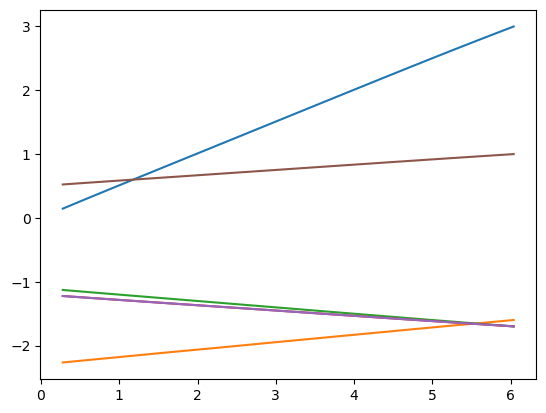

In [31]:
position = [x[0:6] for x in simX]
plt.plot(np.cumsum(simX[:-1,6]),position[1:])
plt.show()

In [32]:
position

[array([ 6.14743967e-33, -2.30000000e+00, -1.10000000e+00, -1.20000000e+00,
        -1.20000000e+00,  5.00000000e-01]),
 array([ 0.14511501, -2.26566224, -1.12909482, -1.22395419, -1.22417742,
         0.52418586]),
 array([ 0.29968578, -2.22949258, -1.16011164, -1.24976562, -1.24993243,
         0.54994767]),
 array([ 0.45882682, -2.19287802, -1.19192397, -1.27661033, -1.27645428,
         0.57647122]),
 array([ 0.61973023, -2.15479725, -1.22401236, -1.30374566, -1.30327865,
         0.60328851]),
 array([ 0.78092959, -2.11667126, -1.25621435, -1.3306283 , -1.3301506 ,
         0.63015514]),
 array([ 0.94176815, -2.079979  , -1.28841118, -1.357436  , -1.35695812,
         0.65696163]),
 array([ 1.10203832, -2.04345397, -1.32049462, -1.38409666, -1.38367195,
         0.68367339]),
 array([ 1.26174894, -2.00615973, -1.35245936, -1.41040049, -1.41029336,
         0.71029187]),
 array([ 1.42097886, -1.96836384, -1.38426267, -1.43663828, -1.43683364,
         0.73683023]),
 array([ 1.57978

In [33]:
xf

array([ 3. , -1.6, -1.7, -1.7, -1.7,  1. ])

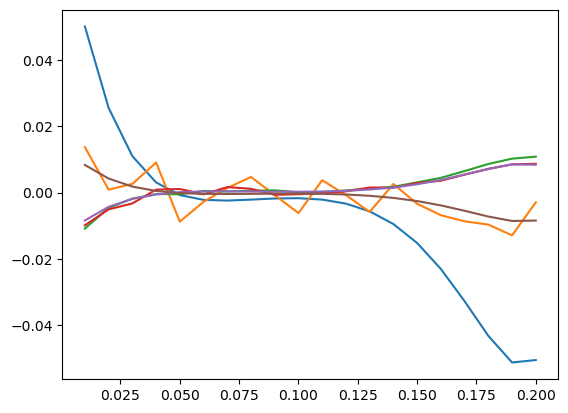

In [34]:
velocity = [x[:6] for x in simU]
plt.plot(np.cumsum(simX[:-1,12]),velocity)
plt.show()

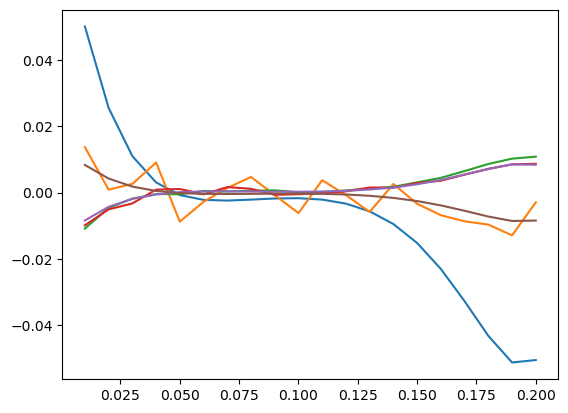

In [35]:
plt.plot(np.cumsum(simX[:-1,12]), [x[0:6] for x in simU])
plt.show()

In [36]:
[x[12] for x in simX]

[0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984,
 0.010000000170534984]

In [37]:
sum([x[12] for x in simX])

DM(0.21)